# Graphs with Pandas Library
- https://pandas.pydata.org/docs/user_guide/visualization.html
- Types of plots
    - ‘bar’ or ‘barh’ for bar plots
    - ‘hist’ for histogram
    - ‘box’ for boxplot
    - ‘kde’ or ‘density’ for density plots
    - ‘area’ for area plots
    - ‘scatter’ for scatter plots
    - ‘hexbin’ for hexagonal bin plots
    - ‘pie’ for pie plots

In [1]:
import pandas as pd
import numpy as np
from pydataset import data

In [2]:
df = data('mtcars')
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
# Pl practise from the link provided above

In [4]:
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

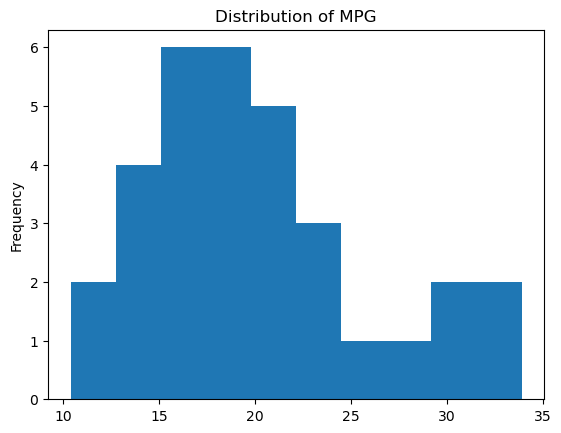

In [6]:
 # 1. Histogram
df['mpg'].plot(kind='hist', title='Distribution of MPG')
plt.show()

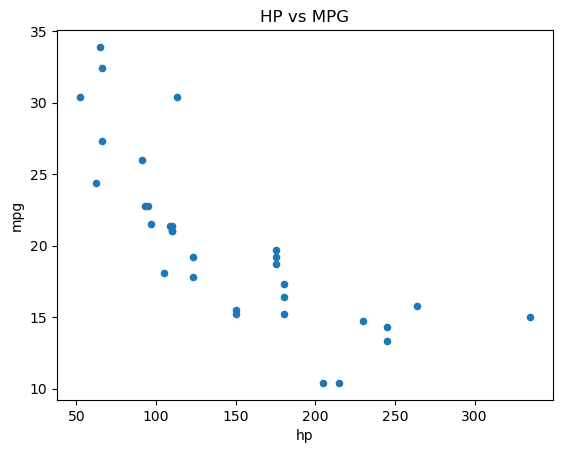

In [7]:
# 2. Scatter Plot
df.plot(kind='scatter', x='hp', y='mpg', title='HP vs MPG')
plt.show()

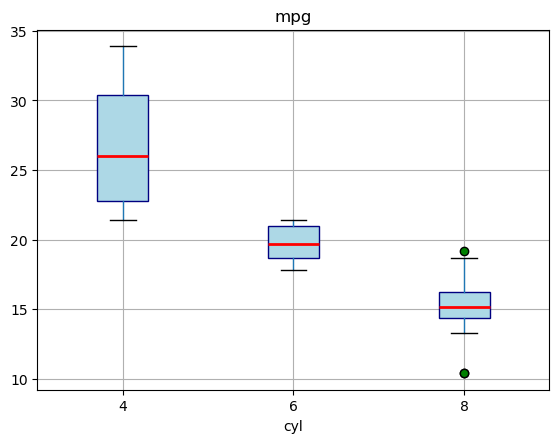

In [8]:
# 3. Boxplot
# 1. Style the box components
props = {
    'patch_artist': True,
    'boxprops': dict(facecolor='lightblue', color='navy'), # Fill and border
    'medianprops': dict(color='red', linewidth=2),        # Median line style
    'flierprops': dict(markerfacecolor='green', marker='o') # Outlier style
}
df.boxplot(column='mpg', by='cyl', **props)
plt.suptitle('')
plt.show()

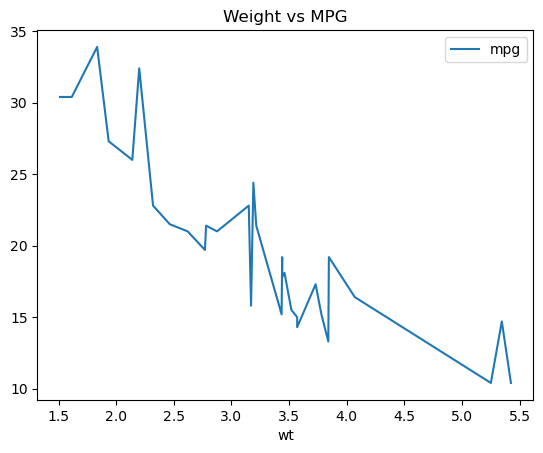

In [9]:
# 4. Line Plot
df.sort_values('wt').plot(x='wt', y='mpg', kind='line', title='Weight vs MPG')
plt.show()

# When to use : Best Tool
- Quick EDA ✅ Pandas
- Custom styling / dashboards- ✅ Matplotlib
- Statistical visualization - ✅ Seaborn

# Try these next (very useful for interviews + projects):
- df.plot(kind='bar') → categorical comparison
- df.plot(kind='density') → distribution understanding
- df.corr() + heatmap → feature relationships
- Subplots: df.plot(subplots=True)

<Axes: >

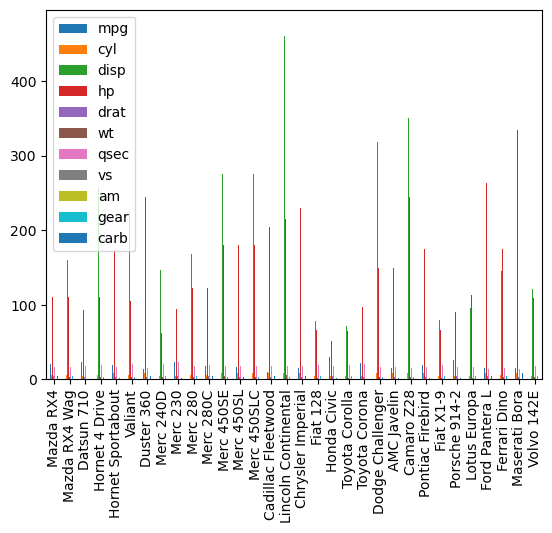

In [10]:
df.plot(kind='bar')

<Axes: ylabel='Density'>

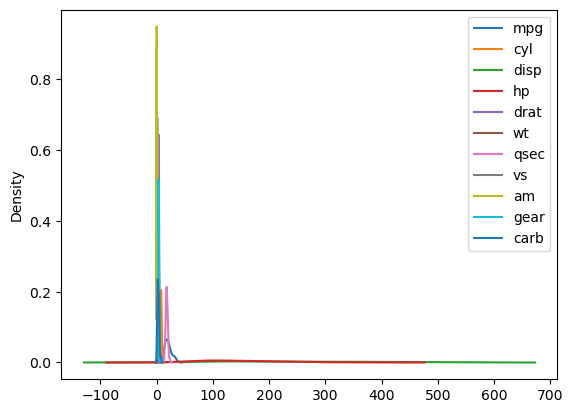

In [11]:
df.plot(kind='density')

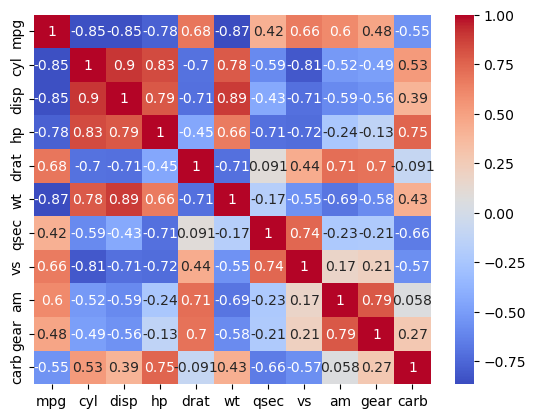

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
corr_matrix = df.corr()

# 2. Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

#### Common Customizations
- Display Numbers: Use annot=True to show the correlation coefficients inside the cells.
- Set Value Limits: Use vmin=-1 and vmax=1 to ensure the colormap is anchored to the full range of possible correlation values (-1 to 1).
- Color Schemes: Common diverging palettes for correlations include 'coolwarm', 'RdBu', or 'BrBG'.
- Remove Redundant Data: Since a correlation matrix is symmetrical, you can use a mask to hide the upper triangle for better clarity:
- The Calculation:
corr_matrix = df.corr(): This is the engine. It takes your DataFrame and compares every column to every other column.
It calculates a "correlation coefficient" (usually Pearson).
+5The result is a new table where 1.0 means perfect match and -1.0 means a perfect opposite.
- The Visualization
sns.heatmap(...): This takes the table from step 2 and assigns a color to every number.
corr_matrix: The data you want to plot.
annot=True: This tells Python to write the actual numbers (e.g., 0.85) inside the boxes. If you have 50+ columns, you might set this to False to avoid clutter.
cmap='coolwarm': This is the "Color Map." It sets the vibe: Blue for negative numbers, Red for positive numbers, and White/Grey for zero.


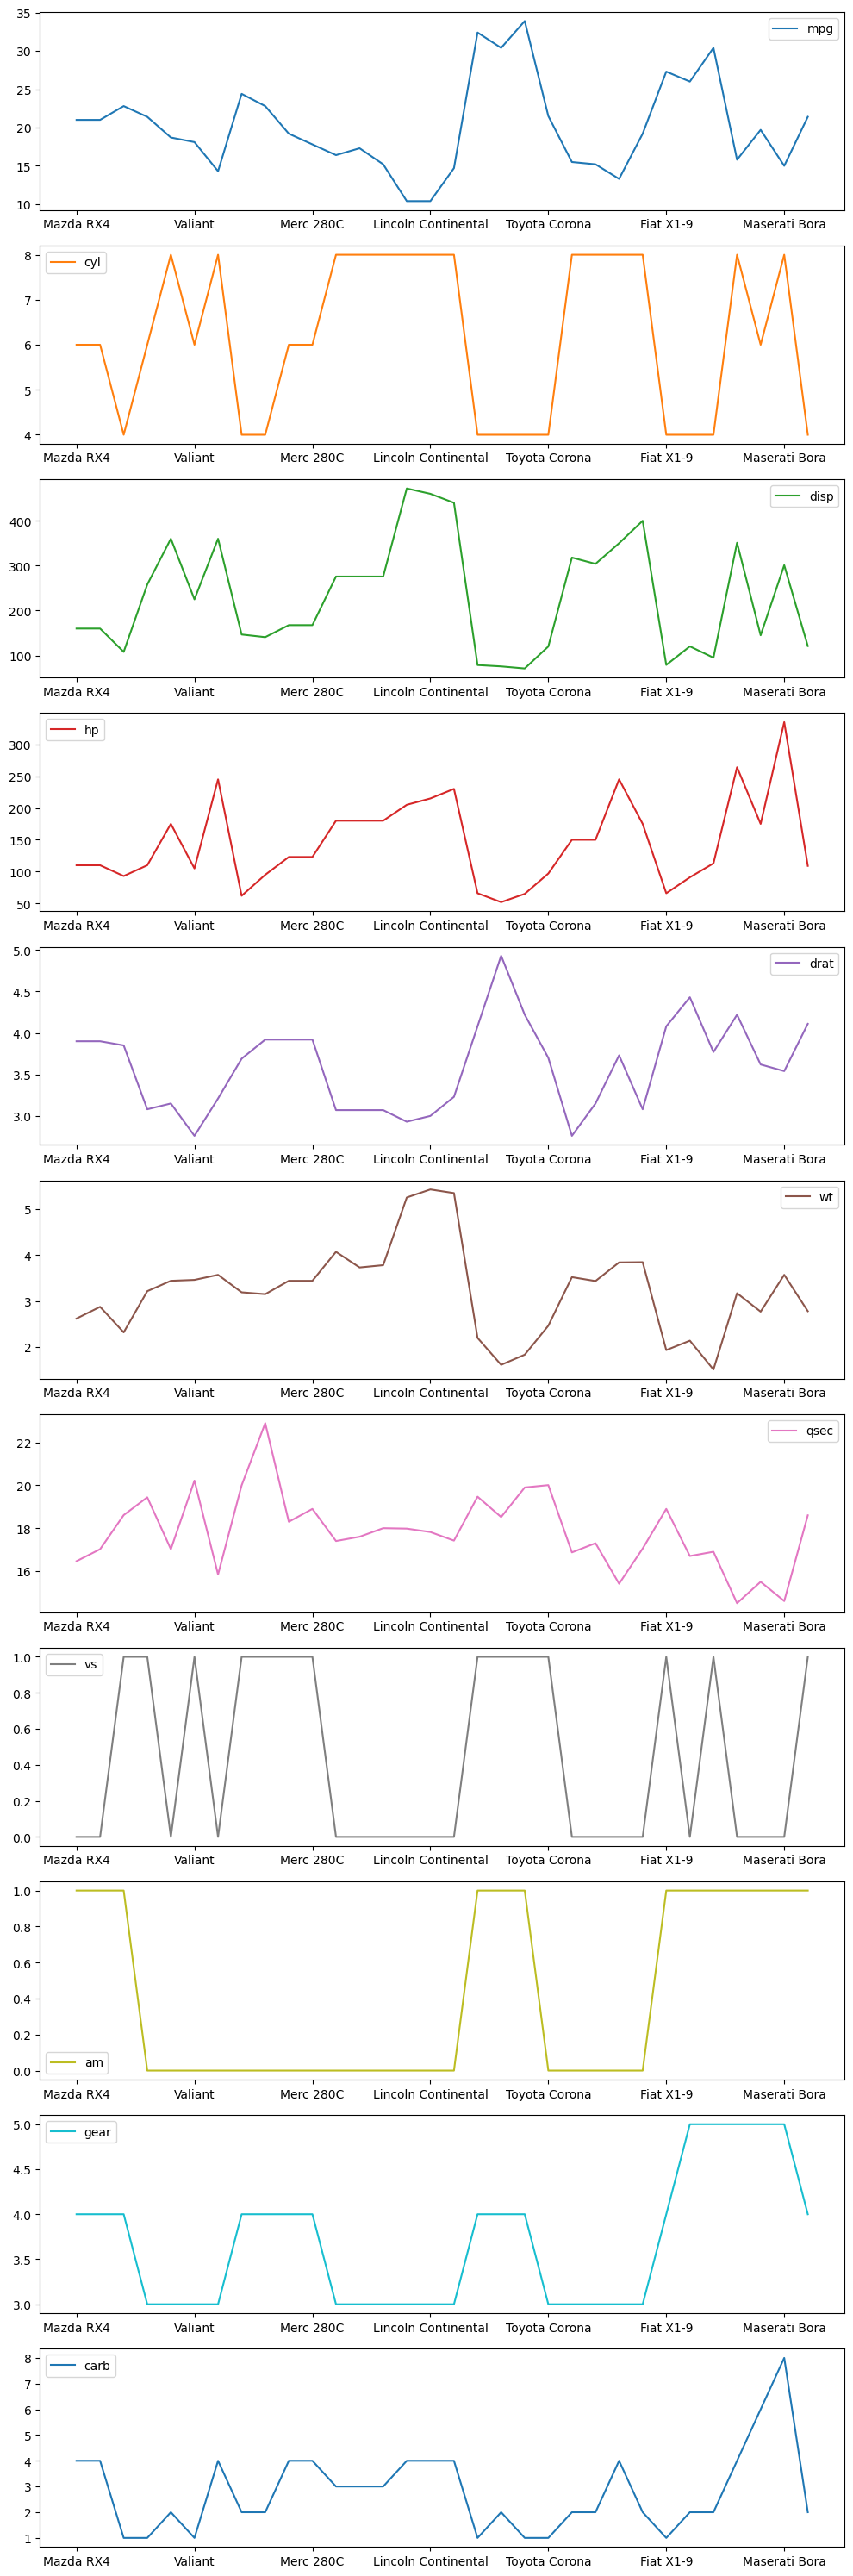

In [13]:
import matplotlib.pyplot as plt

# Use the pandas plot function to create separate charts for each column
df.plot(
    subplots=True,               # Tell pandas to put each variable in its own graph
    layout=(len(df.columns), 1), # Create a grid with as many rows as columns, and 1 column wide, so 11 rows(11 graph stacked top next next) and 11 rows in 1 column.
    figsize=(10, 30),            # Set the canvas size: 10 inches wide and 30 inches tall
    sharex=False,                # Give every graph its own x-axis so car names appear on all rows
    )

# Automatically adjust the padding between the subplots to prevent overlapping labels
plt.tight_layout()

# Render the final figure on the screen
plt.show()